# Correlation Analysis

## Imports and Data Loading


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [28]:
df = pd.read_csv("../data/processed/processed_telco_customer_churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           6043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            4543 non-null   float64
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   6043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       5543 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [30]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()

## Correlation between Features (Without the Target)

### Numeric → Numeric

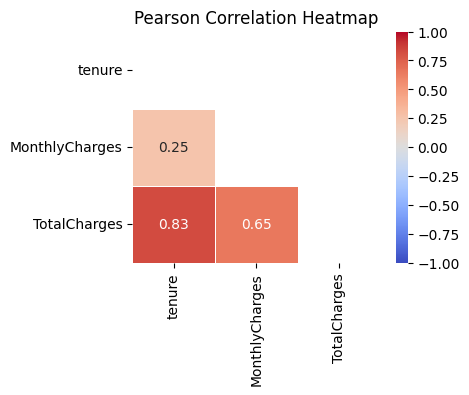

In [31]:
pearson_corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
plt.figure(figsize=(4, 3))
sns.heatmap(pearson_corr, annot=True, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.show()

Since $TotalCharges = tenure . MonthlyCharges$ it makes sense the correlation is so high.

For the modelling it should be interesting to check if the performance of the model when using `tenure` and `MonthlyCharges` is different from when using `TotalCharges`.  

### Numeric → Categorical 

Let's start by creating boxplots of every numerical variable vs the categorical variables. In this way I can visually see how the distributions change. 

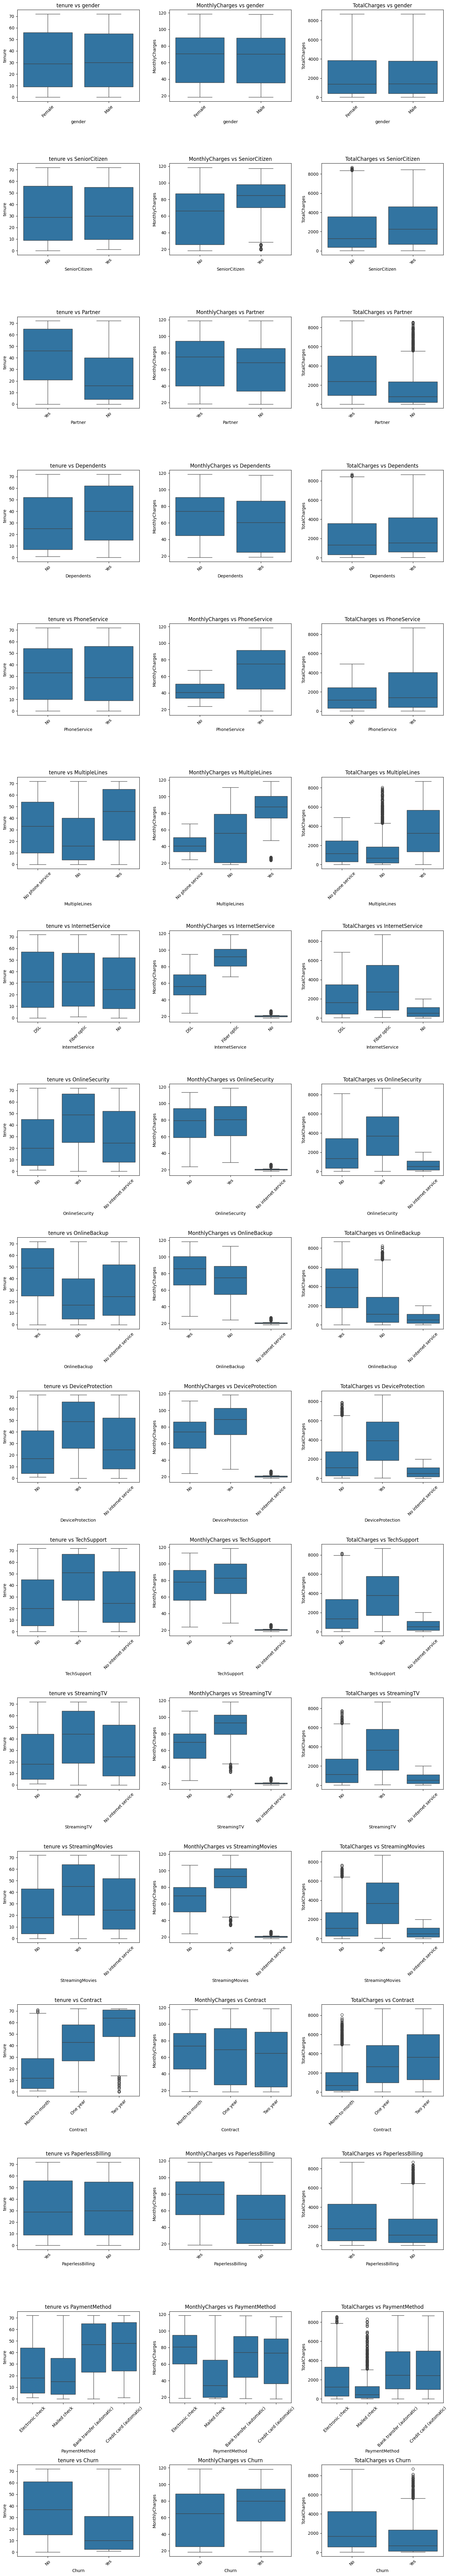

In [32]:
n_rows = len(categorical_cols)
n_cols = len(numeric_cols) 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

for i, cat_col in enumerate(categorical_cols):        
    for j, num_col in enumerate(numeric_cols):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i, j])
        
        axes[i, j].set_title(f'{num_col} vs {cat_col}')
        axes[i, j].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

To see the correlation between numerical and categorical variables with more depth, a statistical measure is easier to perceive in a quicker way. For that I chose to apply the **correlation ratio**. 

$\eta$ (eta), measures the strength of statistical association between variables, especially when their relationship is non-linear. It quantifies how much of the variation in a dependent variable is accounted for by grouping or categorical variables.

The correlation ratio is defined as the square root of the between-group variance divided by the total variance.
$$\eta = \sqrt{\frac{\text{SS}_{between}}{\text{SS}_{total}}} = \sqrt{1 - \frac{\text{SS}_{within}}{\text{SS}_{total}}}$$

In [33]:
def correlation_ratio_test(categorical_cols, numerical_cols, df) -> pd.DataFrame:
    
    """
    Calculates the Correlation Ratio (Eta) for pairs of categorical and numerical variables.
    """
    
    results = []

    for cat_col in categorical_cols:
        for num_col in numerical_cols:
            
            temp_df = df[[cat_col, num_col]].dropna()
            y_total_mean = temp_df[num_col].mean()
            
            group_stats = temp_df.groupby(cat_col)[num_col].agg(['count', 'mean'])
            
            # Sum of Squares Between (SSB)
            ssb = sum(group_stats['count'] * (group_stats['mean'] - y_total_mean)**2)
            sst = sum((temp_df[num_col] - y_total_mean)**2)
            
            # Calculate Eta
            if sst == 0:
                eta = 0.0
            else:
                eta = np.sqrt(ssb / sst)
                
            def eta_interpretation(eta):
                if eta < 0.1:
                    return "Negligible"
                elif eta < 0.3:
                    return "Weak"
                elif eta < 0.5:
                    return "Moderate"
                else:
                    return "Strong"

            results.append({
                'Categorical Variable': cat_col,
                'Numerical Variable': num_col,
                'Correlation Ratio (Eta)': round(eta, 4),
                'Interpretation': eta_interpretation(eta)
            })
            
    # Convert to DataFrame and sort by highest correlation
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='Correlation Ratio (Eta)', ascending=False).reset_index(drop=True)
    
    return results_df

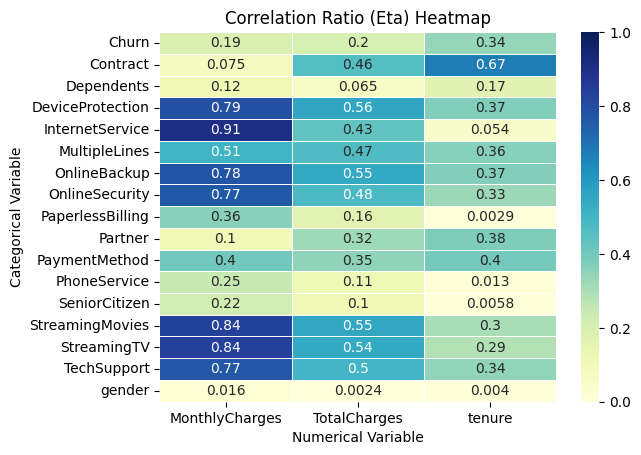

In [34]:
correlation_ratios = correlation_ratio_test(categorical_cols, numeric_cols, df)
seaborn_heatmap_data = correlation_ratios.pivot(index='Categorical Variable', columns='Numerical Variable', values='Correlation Ratio (Eta)')

sns.heatmap(seaborn_heatmap_data, annot=True, cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)

plt.title("Correlation Ratio (Eta) Heatmap")
plt.xlabel("Numerical Variable")
plt.ylabel("Categorical Variable")
plt.show()

As we can see, `MonthlyCharges` has a high correlation with variables that indicate extra services (which makes sense, more services = more money to pay monthly).

There is also a reasonably high correlation between `tenure` and `Contract` - a long term contract (2 Years) means the customer is tied to the company contractually and therefore stays for a longer amount of time.

### Categorical → Categorical

To see the relation between two categorical values, since there are so many, a crosstabulation to see the counts between each pair would be too much to analyze properly.

For this problem I have decided to run a **Chi-Square Test** and **Cramer's V** to analyze the relationship between categorical variables.

- The **Chi-Square Test** checks if the relationship exists - it determines if there is a real relationship between variables in your population or if the patterns in your data occurred purely by chance. It is highly sensitive to sample size so in big datasets, a completely trivial and meaningless relationship will show up as statistically "significant".

- **Cramer's V** measures the effect size or the strength of association -  it calculates how strong the connection actually is, independent of sample size. Cramer's V yields a score from 0 to 1, with 0 being no association  (variables are completely independent) and 1 being perfect association (knowing one variable perfectly predicts the other).

For my type of problem it means that Chi-Square would confirm if the relationship is meaningful and then calculate Cramer's V to understand how strong or important that relationship is.

In [35]:
def calculate_chi_cramer_stats(var1, var2, df) -> dict:
    """Calculate Chi-squared, p-value, and Cramer's V for two categorical variables."""

    contingency_table = pd.crosstab(df[var1], df[var2])            
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    
    min_dim = min(contingency_table.shape) - 1
    
    if min_dim == 0:
        cramers_v = 0.0
    else:
        cramers_v = np.sqrt(chi2 / (n * min_dim))

    def cramers_v_interpretation(v):
        if v < 0.1:
            return "Negligible"
        elif v < 0.3:
            return "Weak"
        elif v < 0.5:
            return "Moderate"
        else:
            return "Strong"
    
    return {
        'Variable 1': var1,
        'Variable 2': var2,
        'Chi-squared': round(chi2, 2),
        'p-value': round(p, 4),
        'Cramer V': round(cramers_v, 4),
        'Cramer V Interpretation': cramers_v_interpretation(cramers_v)
    }

In [36]:
def chi_test(categorical_cols, df, target_col = None) -> pd.DataFrame:
    
    """
    Performs chi-squared tests and calculates Cramer's V for each pair 
    of categorical variables, returning the results in a DataFrame.
    """
    
    results = []

    if target_col is not None:
        for col in categorical_cols:
            if col != target_col:
                stats = calculate_chi_cramer_stats(var1=col, var2=target_col, df=df)
                results.append(stats)
    else:
        for i in range(len(categorical_cols)):
            for j in range(i + 1, len(categorical_cols)):
                var1 = categorical_cols[i]
                var2 = categorical_cols[j]
                stats = calculate_chi_cramer_stats(var1=var1, var2=var2, df=df)
                results.append(stats)
            
    return pd.DataFrame(results)

In [37]:
chi_categ_categ = chi_test(categorical_cols, df)

relevant = chi_categ_categ[(chi_categ_categ['p-value'] < 0.05) & (chi_categ_categ['Cramer V'] > 0.3)] \
    .sort_values(by=['Cramer V', 'Variable 1'], ascending=False)

print("Statistically Significant Relationships (Ranked by Strength):\n")
print(relevant.to_string(index=False))

Statistically Significant Relationships (Ranked by Strength):

      Variable 1       Variable 2  Chi-squared  p-value  Cramer V Cramer V Interpretation
    PhoneService    MultipleLines      7043.00      0.0    1.0000                  Strong
     StreamingTV  StreamingMovies      6586.15      0.0    0.7708                  Strong
DeviceProtection  StreamingMovies      7631.31      0.0    0.7360                  Strong
DeviceProtection      StreamingTV      5973.03      0.0    0.7340                  Strong
  OnlineSecurity      TechSupport      7569.72      0.0    0.7331                  Strong
DeviceProtection      TechSupport      7434.32      0.0    0.7265                  Strong
 InternetService   OnlineSecurity      6328.68      0.0    0.7236                  Strong
 InternetService      TechSupport      6294.47      0.0    0.7217                  Strong
    OnlineBackup      TechSupport      7298.82      0.0    0.7198                  Strong
    OnlineBackup DeviceProtection    

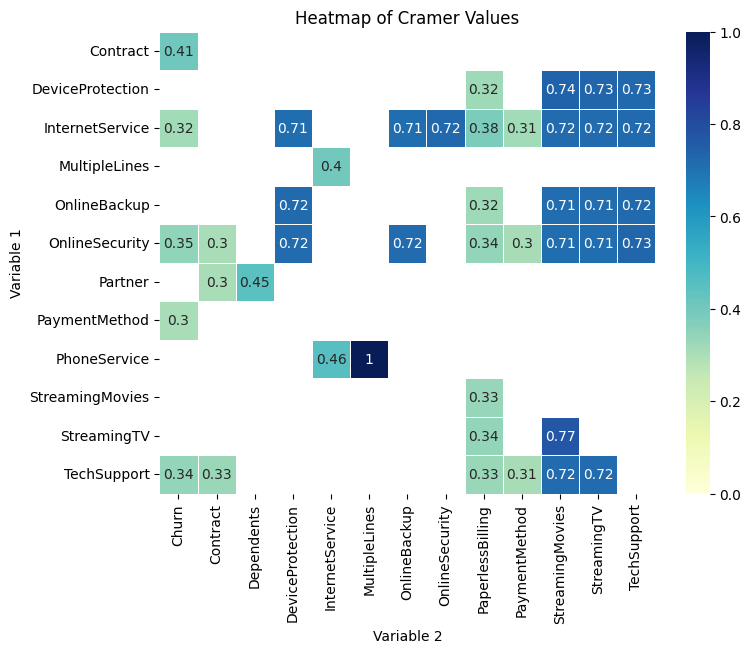

In [45]:
seaborn_heatmap_data_chi = relevant.pivot(index='Variable 1', columns='Variable 2', values='Cramer V')
plt.figure(figsize=(8,6))
sns.heatmap(seaborn_heatmap_data_chi, annot=True, cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)
plt.title('Heatmap of Cramer Values')
plt.show()

As we can see, there is high relationship between the different types of service - being subscribed to one service might mean you're subscribed to others as well.

## Correlation of Variables with the Target

### Numeric → Target

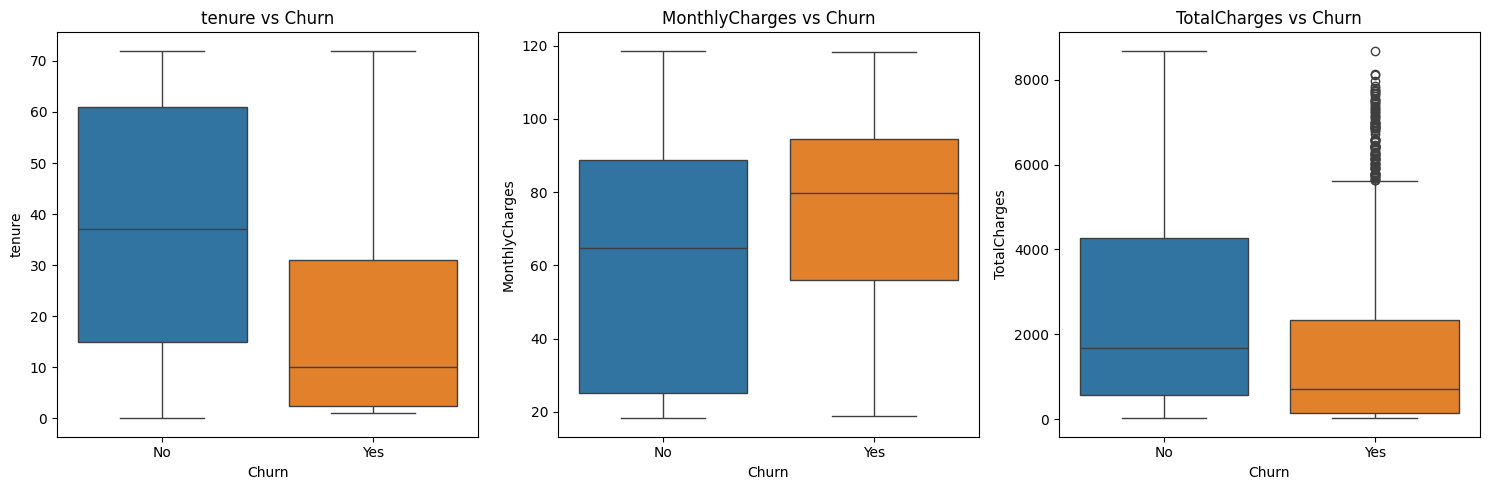

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x="Churn", y=col, data=df, ax=axes[idx], hue="Churn")
    axes[idx].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

### Categorical → Target

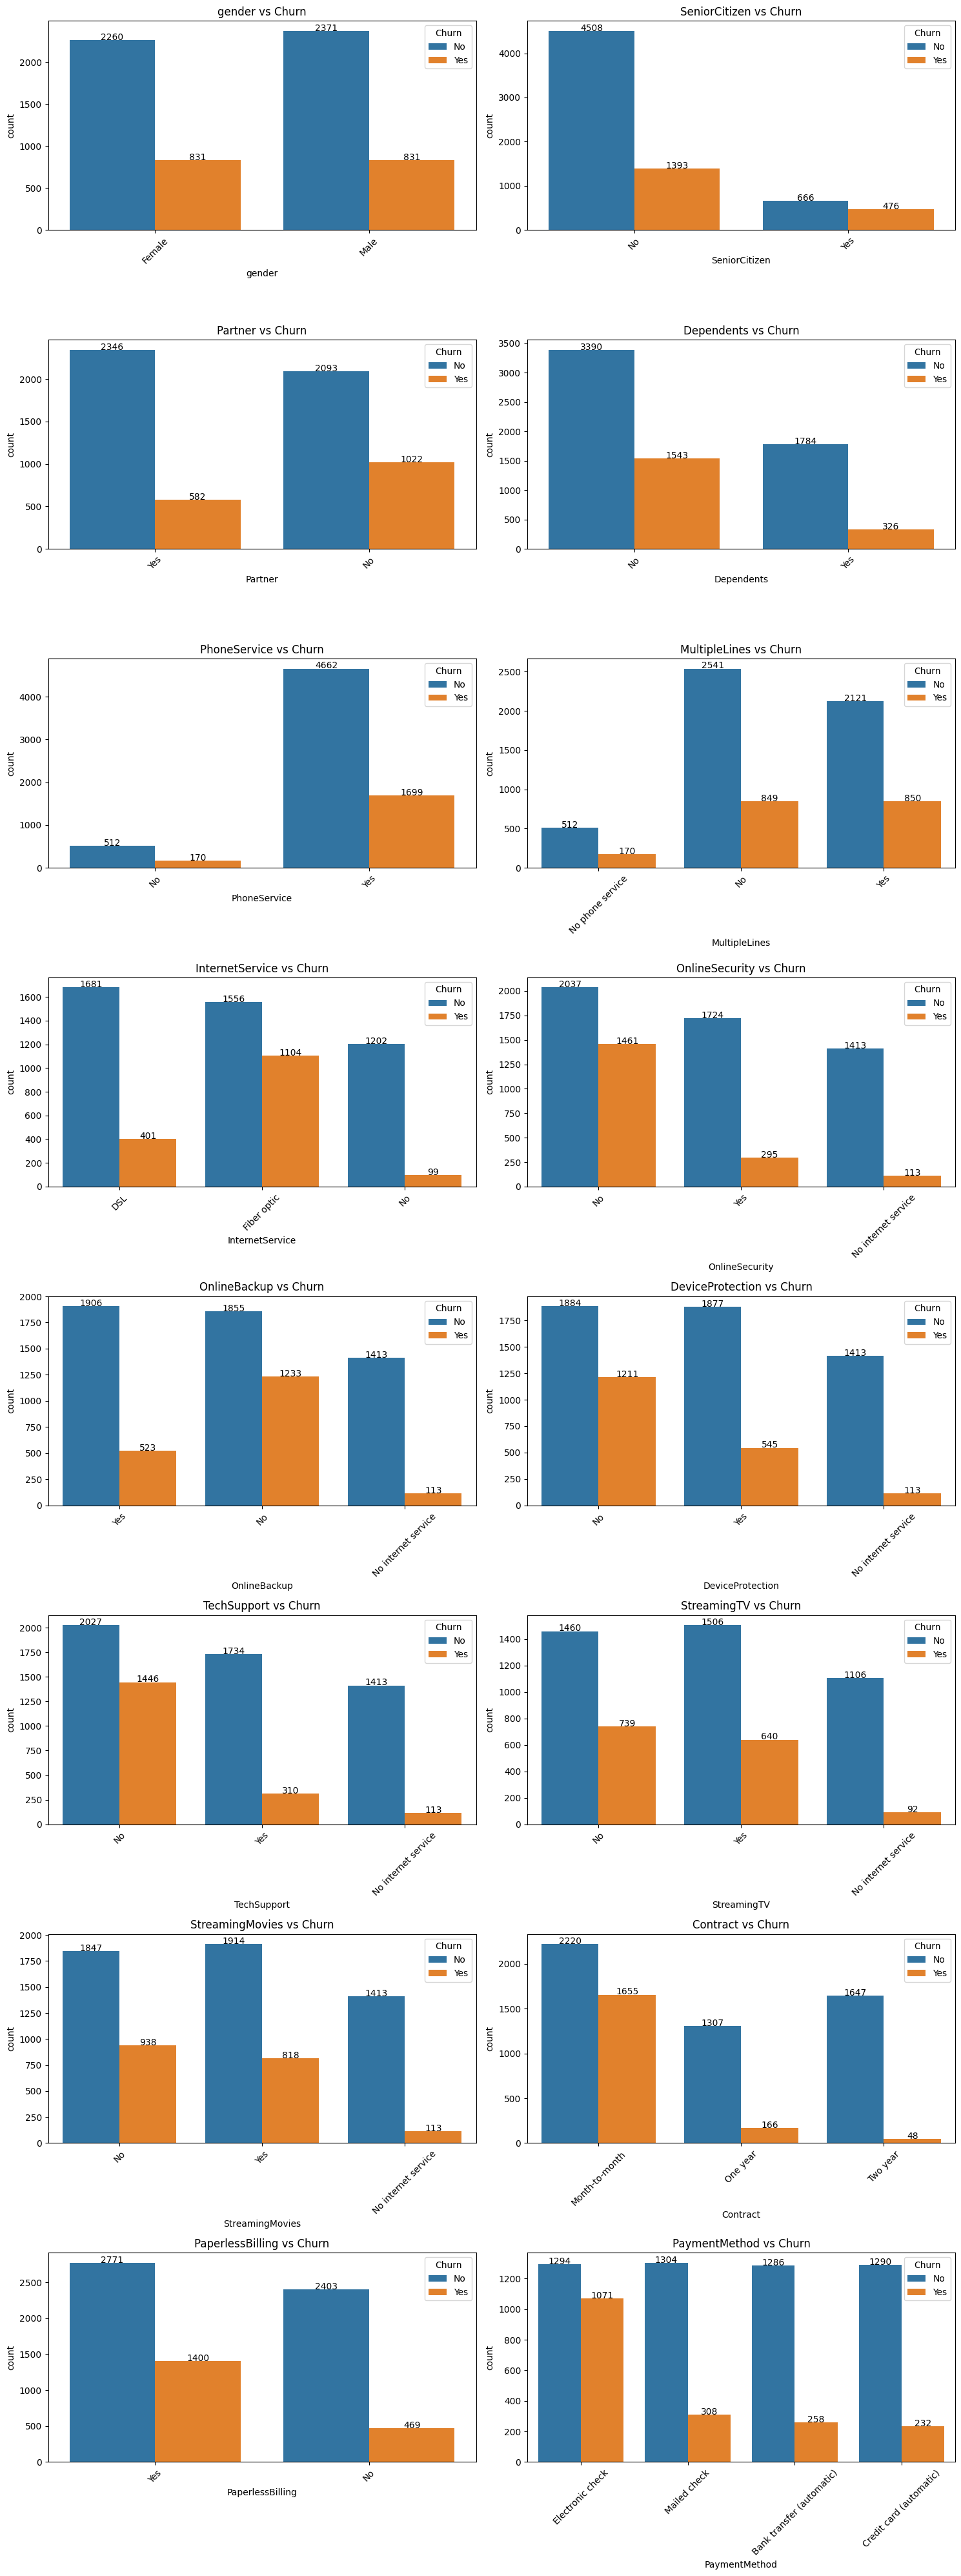

In [15]:
nr_rows = len(categorical_cols) // 2 + (len(categorical_cols) % 2 > 0) - 1  # Exclude "Churn" from the count
nr_cols = 2
fig, axes = plt.subplots(nr_rows, nr_cols, figsize=(15, 5 * nr_rows))

for i, col in enumerate(categorical_cols):
    if col != "Churn":
        row = i // nr_cols
        col_idx = i % nr_cols
        sns.countplot(data=df, x=col, hue="Churn", ax=axes[row, col_idx])
        axes[row, col_idx].set_title(f"{col} vs Churn")
        axes[row, col_idx].legend(title="Churn", loc="upper right")
        axes[row, col_idx].tick_params(axis="x", rotation=45)

for ax in axes.flatten():
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x() + p.get_width() / 2., height + 0.5, int(height), ha="center")

plt.tight_layout()
plt.show()

In [17]:
chi_categ_target = chi_test(categorical_cols, df, target_col="Churn")
chi_categ_target.sort_values(by='Cramer V', ascending=False)

,Variable 1,Variable 2,Chi-squared,p-value,Cramer V,Cramer V Interpretation
13,Contract,Churn,1184.60,0.0000,0.4101,Moderate
7,OnlineSecurity,Churn,850.00,0.0000,0.3474,Moderate
10,TechSupport,Churn,828.20,0.0000,0.3429,Moderate
6,InternetService,Churn,601.18,0.0000,0.3154,Moderate
15,PaymentMethod,Churn,648.14,0.0000,0.3034,Moderate
8,OnlineBackup,Churn,601.81,0.0000,0.2923,Weak
9,DeviceProtection,Churn,558.42,0.0000,0.2816,Weak
12,StreamingMovies,Churn,375.66,0.0000,0.2310,Weak
11,StreamingTV,Churn,286.78,0.0000,0.2275,Weak
14,PaperlessBilling,Churn,258.28,0.0000,0.1915,Weak


For this analysis, we can see the categorical variables that have higher relation to the target are:
- `Contract`
- `OnlineSecurity` 
- `TechSupport` 
- `InternetService` 
- `PaymentMethod` 

**Conclusions:**
Knowing the type of relation between `Contract` and `tenure` (they both signify the amount of time the customer is attached to the time of the customer with the company) we should note down that it might not be good to use both at the same time, but it should be tested.

Altough `OnlineSecurity`, `TechSupport`and `InternetService` seem to relate to `Churn`, their use in a model should be careful because they have a high relationship between each other (as we've seen). 

